# 1. Preuzimanje i inicijalna analiza podataka
## Projekat OnlyFacts - Detekcija lažnih vesti u SAD za 2017. godinu

### 1.1 Ucitavanje biblioteka i podataka

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [2]:
# Ucitavanje podataka
true_df = pd.read_csv('data/true.csv')
fake_df = pd.read_csv('data/fake.csv')

# Dodavanje labele: 1 = istinita vest, 0 = lazna vest
true_df['label'] = 1
fake_df['label'] = 0

print(f'Skup istinitih vesti: {true_df.shape[0]} redova, {true_df.shape[1]} kolona')
print(f'Skup laznih vesti:    {fake_df.shape[0]} redova, {fake_df.shape[1]} kolona')

Skup istinitih vesti: 21417 redova, 5 kolona
Skup laznih vesti:    23481 redova, 5 kolona


### 1.2 Pregled strukture podataka

In [3]:
print('ISTINITE VESTI')
print(true_df.info())
print('\nPrvih 5 redova:')
true_df.head()

ISTINITE VESTI
<class 'pandas.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    21417 non-null  str  
 1   text     21417 non-null  str  
 2   subject  21417 non-null  str  
 3   date     21417 non-null  str  
 4   label    21417 non-null  int64
dtypes: int64(1), str(4)
memory usage: 836.7 KB
None

Prvih 5 redova:


,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [4]:
print('LAZNE VESTI')
print(fake_df.info())
print('\nPrvih 5 redova:')
fake_df.head()

LAZNE VESTI
<class 'pandas.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    23481 non-null  str  
 1   text     23481 non-null  str  
 2   subject  23481 non-null  str  
 3   date     23481 non-null  str  
 4   label    23481 non-null  int64
dtypes: int64(1), str(4)
memory usage: 917.4 KB
None

Prvih 5 redova:


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


### 1.3 Provera nedostajucih vrednosti

In [5]:
print('NEDOSTAJUCE VREDNOSTI')
print('\nIstinite vesti:')
print(true_df.isnull().sum())
print(f'Ukupno: {true_df.isnull().sum().sum()}')

print('\nLazne vesti:')
print(fake_df.isnull().sum())
print(f'Ukupno: {fake_df.isnull().sum().sum()}')

NEDOSTAJUCE VREDNOSTI

Istinite vesti:
title      0
text       0
subject    0
date       0
label      0
dtype: int64
Ukupno: 0

Lazne vesti:
title      0
text       0
subject    0
date       0
label      0
dtype: int64
Ukupno: 0


### 1.4 Provera duplikata

In [6]:
print('DUPLIKATI')
print(f'Duplikati u istinitim vestima: {true_df.duplicated().sum()}')
print(f'Duplikati u laznim vestima:    {fake_df.duplicated().sum()}')

# Provera duplikata samo po tekstu, u slucaju da imamo isti tekst sa razlicitim naslovima
print(f'\nDuplikati po koloni "text" - istinite: {true_df["text"].duplicated().sum()}')
print(f'Duplikati po koloni "text" - lazne:    {fake_df["text"].duplicated().sum()}')

DUPLIKATI
Duplikati u istinitim vestima: 206
Duplikati u laznim vestima:    3

Duplikati po koloni "text" - istinite: 225
Duplikati po koloni "text" - lazne:    6026


### 1.5 Spajanje u jedan dataset i distribucija klasa (provera balansiranosti klasa)

In [7]:
# Spajanje skupova
df = pd.concat([true_df, fake_df], ignore_index=True)
print(f'Ukupan broj clanaka: {df.shape[0]}')
print(f'\nDistribucija klasa:')
print(df['label'].value_counts())
print(f'\nProcenat istinitih: {df["label"].mean()*100:.1f}%')
print(f'Procenat laznih:    {(1 - df["label"].mean())*100:.1f}%')

Ukupan broj clanaka: 44898

Distribucija klasa:
label
0    23481
1    21417
Name: count, dtype: int64

Procenat istinitih: 47.7%
Procenat laznih:    52.3%


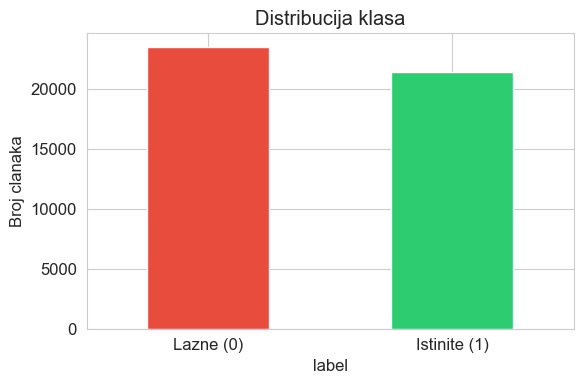

In [8]:
# Vizuelizacija distribucije klasa
fig, ax = plt.subplots(figsize=(6, 4))
df['label'].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'], ax=ax)
ax.set_xticklabels(['Lazne (0)', 'Istinite (1)'], rotation=0)
ax.set_title('Distribucija klasa')
ax.set_ylabel('Broj clanaka')
plt.tight_layout()
plt.show()

### 1.6 Analiza kategorija (subject)

In [9]:
print('Kategorije u istinitim vestima:')
print(true_df['subject'].value_counts())
print(f'\nKategorije u laznim vestima:')
print(fake_df['subject'].value_counts())

Kategorije u istinitim vestima:
subject
politicsNews    11272
worldnews       10145
Name: count, dtype: int64

Kategorije u laznim vestima:
subject
News               9050
politics           6841
left-news          4459
Government News    1570
US_News             783
Middle-east         778
Name: count, dtype: int64


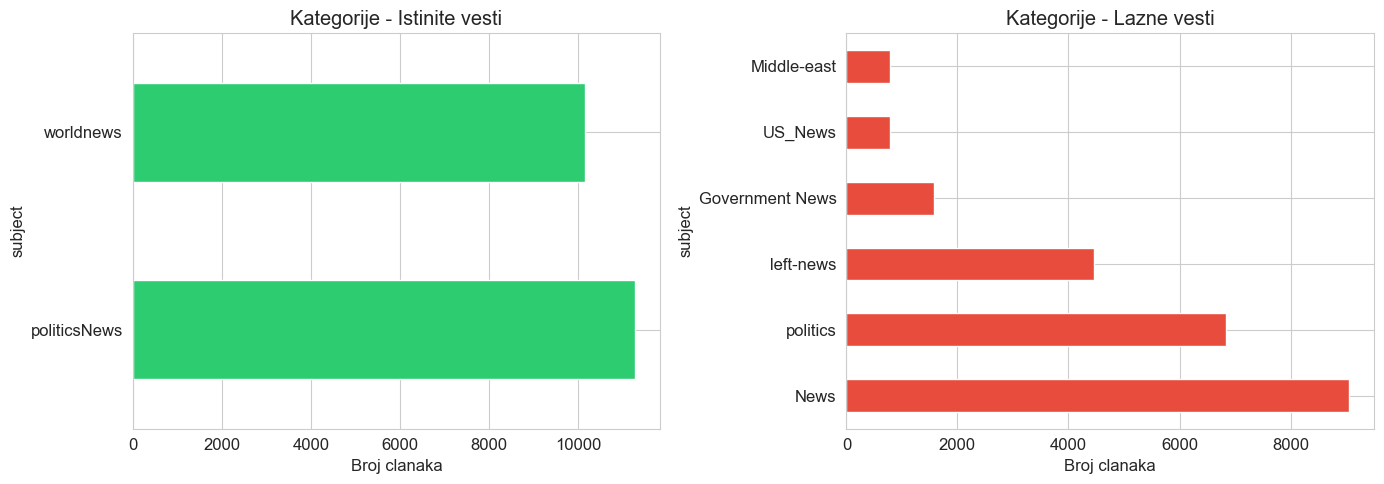

In [10]:
# Vizuelizacija kategorija po klasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

true_df['subject'].value_counts().plot(kind='barh', ax=axes[0], color='#2ecc71')
axes[0].set_title('Kategorije - Istinite vesti')
axes[0].set_xlabel('Broj clanaka')

fake_df['subject'].value_counts().plot(kind='barh', ax=axes[1], color='#e74c3c')
axes[1].set_title('Kategorije - Lazne vesti')
axes[1].set_xlabel('Broj clanaka')

plt.tight_layout()
plt.show()

### 1.7 Statistike teksta

In [11]:
# Duzina teksta (broj karaktera i broj reci)
df['text_length'] = df['text'].astype(str).apply(len)
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))
df['title_length'] = df['title'].astype(str).apply(len)

print('STATISTIKE TEKSTA')
print('\nBroj reci u clanku:')
print(df.groupby('label')['word_count'].describe().round(1))
print('\nDuzina naslova (karakteri):')
print(df.groupby('label')['title_length'].describe().round(1))

STATISTIKE TEKSTA

Broj reci u clanku:
         count   mean    std  min    25%    50%    75%     max
label                                                         
0      23481.0  423.2  408.4  0.0  240.0  363.0  506.0  8135.0
1      21417.0  385.6  274.0  0.0  148.0  359.0  525.0  5172.0

Duzina naslova (karakteri):
         count  mean   std   min   25%   50%    75%    max
label                                                     
0      23481.0  94.2  27.2   8.0  77.0  90.0  105.0  286.0
1      21417.0  64.7   9.2  26.0  59.0  64.0   70.0  133.0


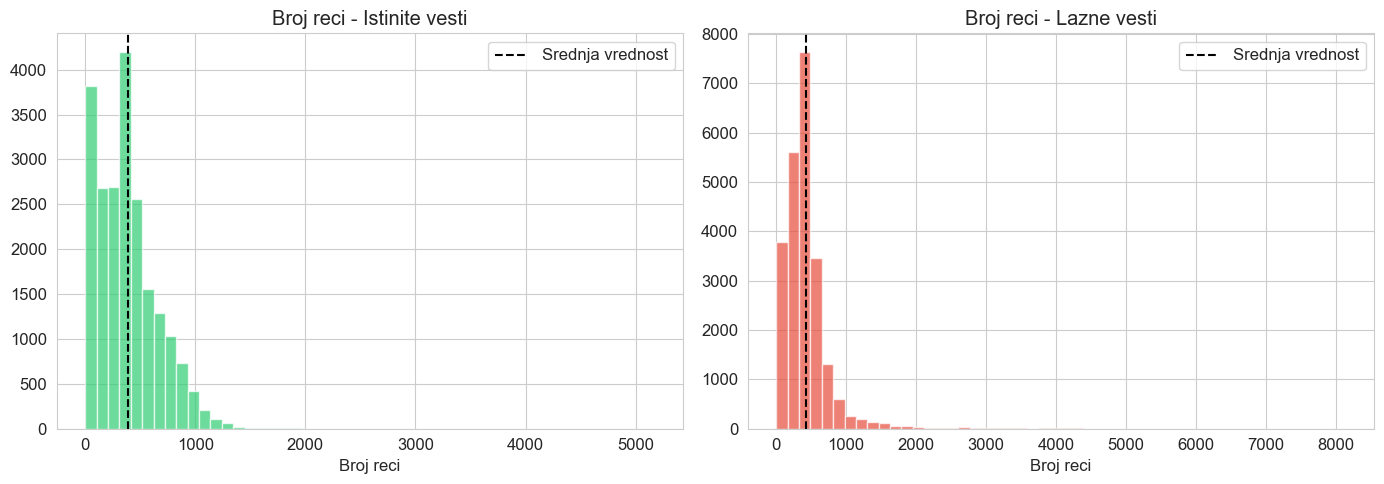

In [12]:
# Vizuelizacija distribucije duzine teksta po klasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['label']==1]['word_count'].hist(bins=50, ax=axes[0], color='#2ecc71', alpha=0.7)
axes[0].set_title('Broj reci - Istinite vesti')
axes[0].set_xlabel('Broj reci')
axes[0].axvline(df[df['label']==1]['word_count'].mean(), color='black', linestyle='--', label='Srednja vrednost')
axes[0].legend()

df[df['label']==0]['word_count'].hist(bins=50, ax=axes[1], color='#e74c3c', alpha=0.7)
axes[1].set_title('Broj reci - Lazne vesti')
axes[1].set_xlabel('Broj reci')
axes[1].axvline(df[df['label']==0]['word_count'].mean(), color='black', linestyle='--', label='Srednja vrednost')
axes[1].legend()

plt.tight_layout()
plt.show()

### 1.8 Provera praznih/kratkih tekstova

In [13]:
# Clanci sa praznim ili jako kratkim tekstom (manje od 10 reci)
short_texts = df[df['word_count'] < 10]
print(f'Broj clanaka sa manje od 10 reci: {len(short_texts)}')
if len(short_texts) > 0:
    print('\nPrimeri kratkih tekstova:')
    print(short_texts[['title', 'text', 'label']].head(10))

# Prazni naslovi
empty_titles = df[df['title'].astype(str).str.strip() == '']
print(f'\nBroj clanaka sa praznim naslovom: {len(empty_titles)}')

Broj clanaka sa manje od 10 reci: 867

Primeri kratkih tekstova:
                                                   title  \
8970                      Graphic: Supreme Court roundup   
30775  https://100percentfedup.com/served-roy-moore-v...   
32340  TAKE OUR POLL: Who Do You Think President Trum...   
32458  Joe Scarborough BERATES Mika Brzezinski Over “...   
32534  MY FAVORITE EXCUSES…Featuring Hillary Rotten C...   
32607  WATCH TUCKER CARLSON Scorch Sanctuary City May...   
32642  MAYOR OF SANCTUARY CITY: Trump Trying To Make ...   
32653  SHOCKER: Public School Turns Computer Lab Into...   
32658  BOOM! SEAN SPICER: “Trump Sold Hotels In Russi...   
32664  MICHAEL FLYNN’S LAWYER Releases Statement Scor...   

                                                    text  label  
8970                                                          1  
30775  https://100percentfedup.com/served-roy-moore-v...      0  
32340                                                         0  
32458     

### 1.9 Najcesce reci po klasi

In [14]:
def get_top_words(texts, n=20):
    """Izdvaja n najcescih reci iz serije tekstova (bez kratkih reci)."""
    all_words = []
    for text in texts.astype(str):
        # Samo slova, lowercase
        words = re.findall(r'[a-zA-Z]{3,}', text.lower())
        all_words.extend(words)
    return Counter(all_words).most_common(n)

top_true = get_top_words(df[df['label']==1]['text'])
top_fake = get_top_words(df[df['label']==0]['text'])


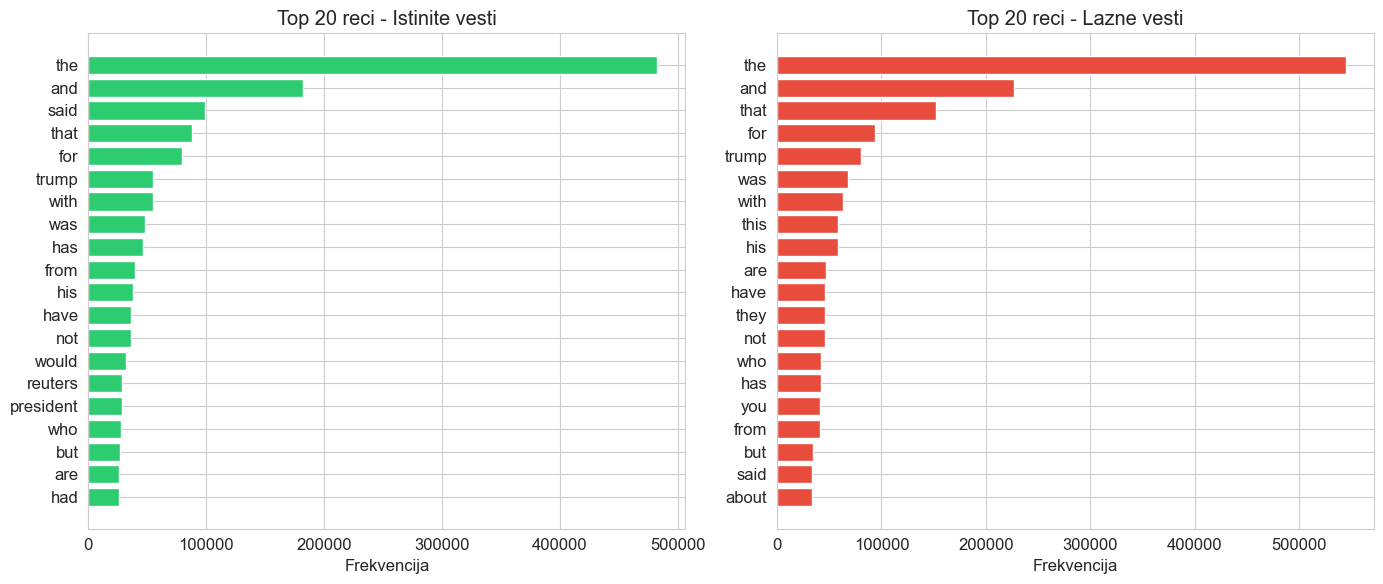

In [15]:
# Vizuelizacija top 20 reci po klasi
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

words_true, counts_true = zip(*top_true)
axes[0].barh(range(len(words_true)), counts_true, color='#2ecc71')
axes[0].set_yticks(range(len(words_true)))
axes[0].set_yticklabels(words_true)
axes[0].invert_yaxis()
axes[0].set_title('Top 20 reci - Istinite vesti')
axes[0].set_xlabel('Frekvencija')

words_fake, counts_fake = zip(*top_fake)
axes[1].barh(range(len(words_fake)), counts_fake, color='#e74c3c')
axes[1].set_yticks(range(len(words_fake)))
axes[1].set_yticklabels(words_fake)
axes[1].invert_yaxis()
axes[1].set_title('Top 20 reci - Lazne vesti')
axes[1].set_xlabel('Frekvencija')

plt.tight_layout()
plt.show()

### 1.10 Prisustvo URL-ova, specijalnih karaktera i velikih slova

In [19]:
# Analiza posebnih karakteristika teksta
df['has_url'] = df['text'].astype(str).str.contains(r'http[s]?://|www\.', regex=True)
df['exclamation_count'] = df['text'].astype(str).str.count('!')
df['caps_ratio'] = df['text'].astype(str).apply(
    lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1)
)


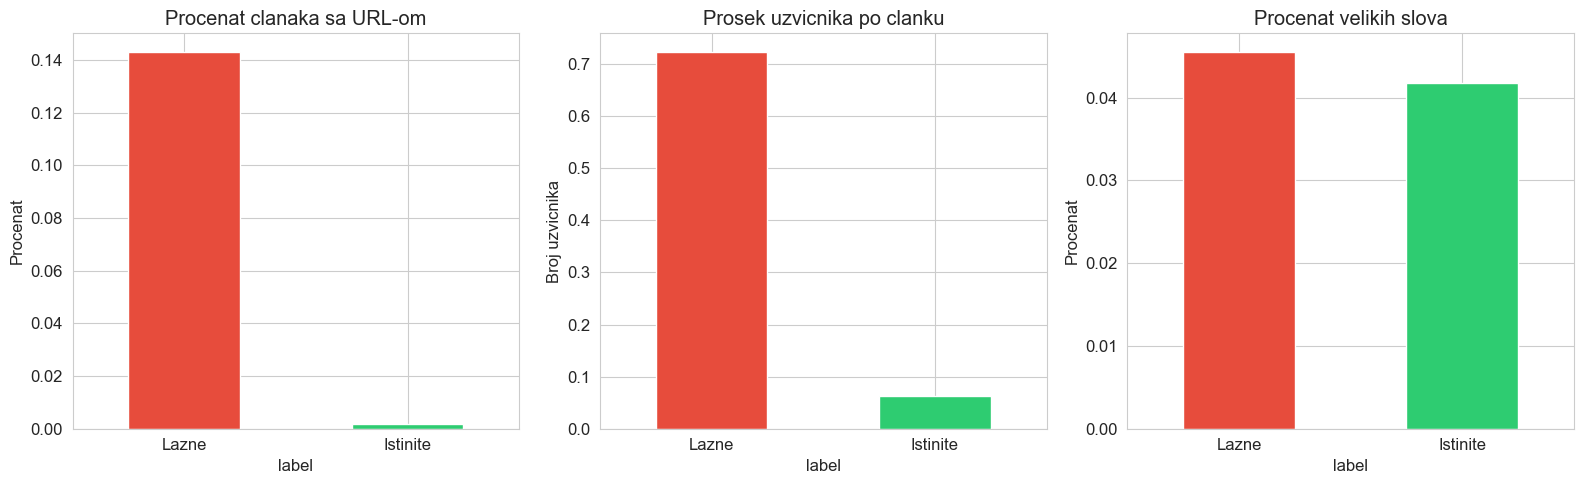

In [17]:
# Vizuelizacija razlika u stilu pisanja
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# URL-ovi
df.groupby('label')['has_url'].mean().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Procenat clanaka sa URL-om')
axes[0].set_xticklabels(['Lazne', 'Istinite'], rotation=0)
axes[0].set_ylabel('Procenat')

# Uzvicnici
df.groupby('label')['exclamation_count'].mean().plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'])
axes[1].set_title('Prosek uzvicnika po clanku')
axes[1].set_xticklabels(['Lazne', 'Istinite'], rotation=0)
axes[1].set_ylabel('Broj uzvicnika')

# Velika slova
df.groupby('label')['caps_ratio'].mean().plot(kind='bar', ax=axes[2], color=['#e74c3c', '#2ecc71'])
axes[2].set_title('Procenat velikih slova')
axes[2].set_xticklabels(['Lazne', 'Istinite'], rotation=0)
axes[2].set_ylabel('Procenat')

plt.tight_layout()
plt.show()